# **Capstone - Machine Learning Based Intrusion Detection System**

#**Data Importing and EDA**

In [1]:
# Importing Required Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
#Pulling down notebook and datafile from GitHub
!git clone https://github.com/anthonyfeaster/UCB-AIML.git
%cd /content/UCB-AIML/Capstone
!ls
!ls data

Cloning into 'UCB-AIML'...
remote: Enumerating objects: 274, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 274 (delta 46), reused 0 (delta 0), pack-reused 192 (from 1)
Receiving objects: 100% (274/274), 14.68 MiB | 3.68 MiB/s, done.
Resolving deltas: 100% (125/125), done.
Updating files: 100% (17/17), done.
/content/UCB-AIML/Capstone
capstone.ipynb	data  README.md
network_traffic_data.csv


In [3]:
#Creating a dataframe from the csv
df = pd.read_csv('data/network_traffic_data.csv')


In [4]:
df.head()

,Duration,Protocol,SourceIP,DestinationIP,SourcePort,DestinationPort,PacketCount,ByteCount,Label
0,24.077749,TCP,192.168.1.239,192.168.1.234,8055,1,827,198244,Attack
1,97.252384,ICMP,192.168.1.176,192.168.1.82,63174,687,673,1202973,Normal
2,85.842654,TCP,192.168.1.120,192.168.1.113,30873,570,319,984671,Attack
3,79.196991,UDP,192.168.1.212,192.168.1.140,4410,683,375,36284,Normal
4,34.928018,TCP,192.168.1.17,192.168.1.223,4702,989,465,817463,Normal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Duration         2000 non-null   float64
 1   Protocol         2000 non-null   object 
 2   SourceIP         2000 non-null   object 
 3   DestinationIP    2000 non-null   object 
 4   SourcePort       2000 non-null   int64  
 5   DestinationPort  2000 non-null   int64  
 6   PacketCount      2000 non-null   int64  
 7   ByteCount        2000 non-null   int64  
 8   Label            2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [6]:
#Printing Number of Rows and Columns plus Column Names
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f"Column Names: {df.columns.tolist()}")

Rows: 2000, Columns: 9
Column Names: ['Duration', 'Protocol', 'SourceIP', 'DestinationIP', 'SourcePort', 'DestinationPort', 'PacketCount', 'ByteCount', 'Label']


In [7]:
df.describe(include='object')

,Protocol,SourceIP,DestinationIP,Label
count,2000,2000,2000,2000
unique,3,255,255,2
top,TCP,192.168.1.177,192.168.1.226,Attack
freq,690,16,17,1022


In [8]:
#Renaming the traffic classification to industry standard terms
df['Label'] = df['Label'].replace({
    'Normal': 'Benign',
    'Attack': 'Malicious'
})

In [9]:
traffic_summary = df['Label'].value_counts().reset_index()
traffic_summary.columns = ['Traffic', 'Count']
traffic_summary['Percentage'] = (traffic_summary['Count'] / traffic_summary['Count'].sum() * 100).map("{:.2f}%".format)

print(traffic_summary)

     Traffic  Count Percentage
0  Malicious   1022     51.10%
1     Benign    978     48.90%


In [10]:
protocol_summary = df['Protocol'].value_counts().reset_index()
protocol_summary.columns = ['Protocol', 'Count']
protocol_summary['Percentage'] = (protocol_summary['Count'] / protocol_summary['Count'].sum() * 100).map("{:.2f}%".format)

protocol_summary

,Protocol,Count,Percentage
0,TCP,690,34.50%
1,ICMP,658,32.90%
2,UDP,652,32.60%


The traffic type appears to be pretty balance with the Malicious traffic being ~51% and Benign traffic being ~49%. It is interesting that 2/3 of the traffic protocol is almost split evenly between TCP and UDP with the remainder being network pings.

In [11]:
#Looking for Missing Values
df.isnull().sum()

,0
Duration,0
Protocol,0
SourceIP,0
DestinationIP,0
SourcePort,0
DestinationPort,0
PacketCount,0
ByteCount,0
Label,0


No missing values were found

In [12]:
# Checking for Duplicate Values

df.duplicated().sum()

np.int64(0)

No duplicate values were found

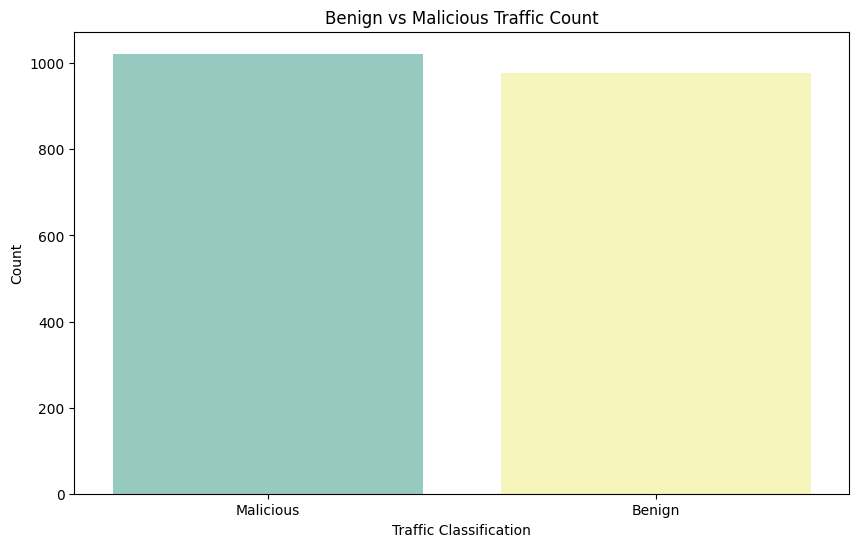

In [13]:
#Creating countplot for traffic count
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df, palette='Set3', hue='Label')
plt.title('Benign vs Malicious Traffic Count')
plt.xlabel('Traffic Classification')
plt.ylabel('Count')
plt.show()


Max Malicious Traffic Count for Any Destination Port: 8.0



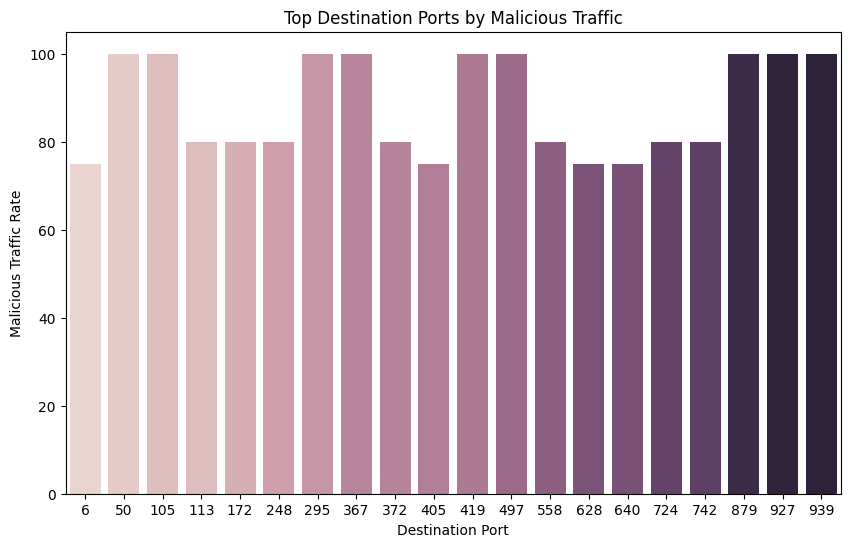

In [14]:
#Evaluating malicious traffic by top destination ports
port_summary = df.groupby('DestinationPort')['Label'].value_counts().unstack().fillna(0)

port_summary['Total_Traffic'] = port_summary.sum(axis=1)

print(f"\nMax Malicious Traffic Count for Any Destination Port: {port_summary['Total_Traffic'].max()}")

print()
port_summary['MaliciousPCT'] = ((port_summary['Malicious']) / (port_summary['Total_Traffic']) * 100)#.map("{:.2f}%".format)
port_summary_fld = port_summary[port_summary['Total_Traffic'] > 3]
top_malicious_ports = port_summary_fld.sort_values(by='MaliciousPCT', ascending=False).head(20).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(data=top_malicious_ports, x='DestinationPort', y='MaliciousPCT', hue='DestinationPort', legend=False)#palette='Set2')
plt.title('Top Destination Ports by Malicious Traffic')
plt.xlabel('Destination Port')
plt.ylabel('Malicious Traffic Rate')
plt.show()


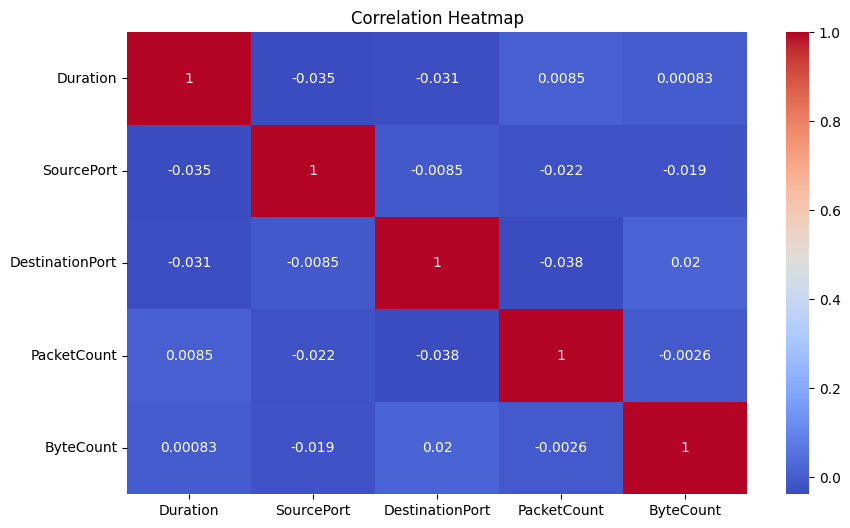

In [15]:
numerical_columns = ["Duration", "SourcePort", "DestinationPort", "PacketCount", "ByteCount"]

plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [16]:
df['DurationMinutes'] = df['Duration'] / 60
df['PacketCountPerMinute'] = df['PacketCount'] / df['DurationMinutes']

df[['Duration', 'DurationMinutes', 'PacketCount', 'PacketCountPerMinute']].head(20)

,Duration,DurationMinutes,PacketCount,PacketCountPerMinute
0,24.077749,0.401296,827,2060.823840
1,97.252384,1.620873,673,415.208333
2,85.842654,1.430711,319,222.966080
3,79.196991,1.319950,375,284.101702
4,34.928018,0.582134,465,798.785651
5,31.135166,0.518919,766,1476.144349
6,22.896530,0.381609,361,945.994886
7,29.768149,0.496136,709,1429.044166
8,65.646803,1.094113,105,95.968115
9,22.845303,0.380755,224,588.304730


Looking to see if there is any correlation between the duration of the connection and the number of packets sent/received

In [17]:
src_duration_fld = df.groupby('SourceIP')['Duration'].agg(FlowCount='count', AverageDuration='mean', TotalDuration="sum").reset_index()
src_duration_fld = src_duration_fld.sort_values(by='AverageDuration', ascending=False)

src_duration_fld.head(10)

,SourceIP,FlowCount,AverageDuration,TotalDuration
186,192.168.1.37,3,84.113441,252.340323
69,192.168.1.161,7,77.846858,544.928003
57,192.168.1.150,4,77.493791,309.975162
182,192.168.1.33,5,73.446012,367.230060
65,192.168.1.158,8,73.218783,585.750266
145,192.168.1.23,5,72.815416,364.077078
13,192.168.1.110,11,72.404504,796.449542
153,192.168.1.237,6,69.791564,418.749384
249,192.168.1.94,7,68.661945,480.633613
8,192.168.1.106,8,68.601636,548.813092


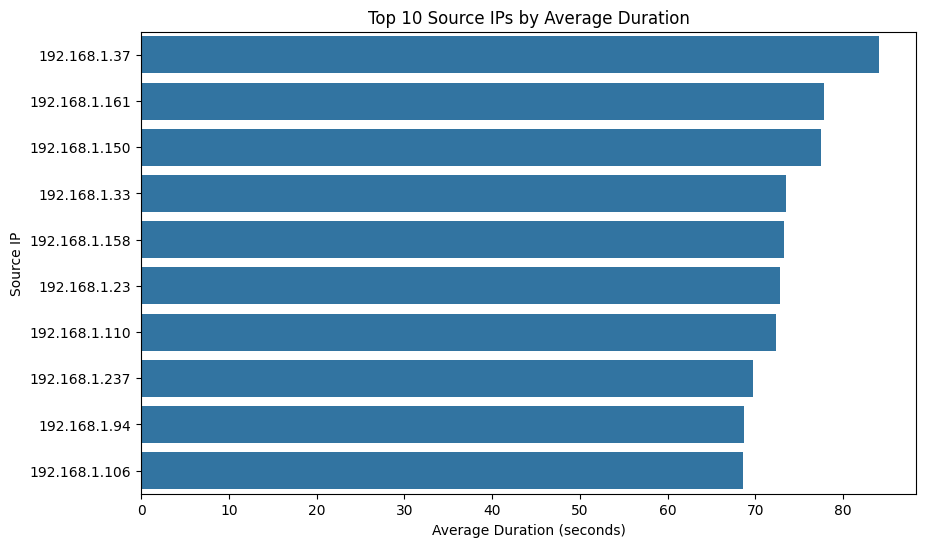

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(x='AverageDuration', y='SourceIP', data=src_duration_fld.head(10))
plt.title('Top 10 Source IPs by Average Duration')
plt.xlabel('Average Duration (seconds)')
plt.ylabel('Source IP')
plt.show()

In [19]:
dst_duration_fld = df.groupby('DestinationIP')['Duration'].agg(FlowCount='count', AverageDuration='mean', TotalDuration="sum").reset_index()
dst_duration_fld = dst_duration_fld.sort_values(by='AverageDuration', ascending=False)

dst_duration_fld.head(10)


,DestinationIP,FlowCount,AverageDuration,TotalDuration
54,192.168.1.148,4,90.142014,360.568057
121,192.168.1.208,6,73.927282,443.563694
25,192.168.1.121,8,72.471898,579.775183
116,192.168.1.203,6,72.183680,433.102079
192,192.168.1.42,6,72.008695,432.052173
207,192.168.1.56,6,70.527066,423.162397
132,192.168.1.218,7,70.371617,492.601322
109,192.168.1.198,6,70.033668,420.202010
138,192.168.1.223,6,69.646161,417.876969
17,192.168.1.114,6,69.292208,415.753248


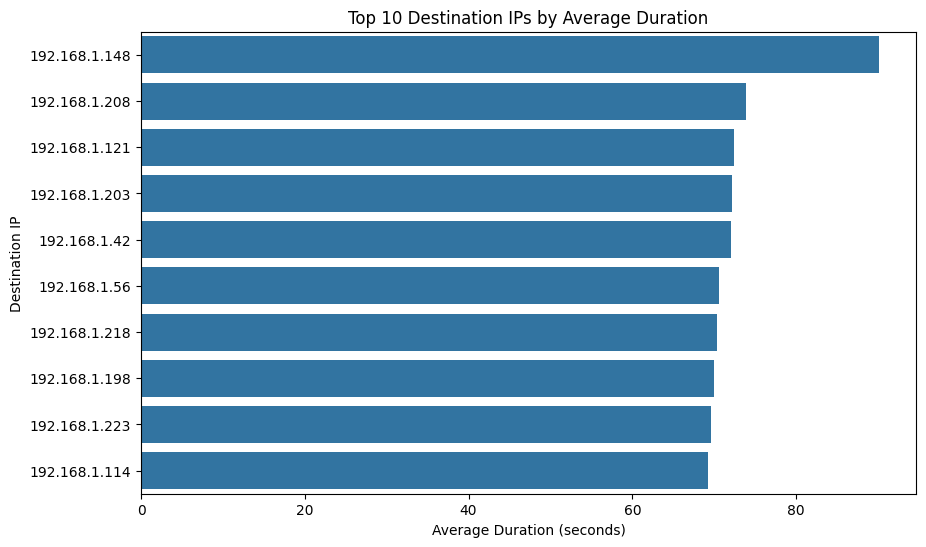

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='AverageDuration', y='DestinationIP', data=dst_duration_fld.head(10))
plt.title('Top 10 Destination IPs by Average Duration')
plt.xlabel('Average Duration (seconds)')
plt.ylabel('Destination IP')
plt.show()

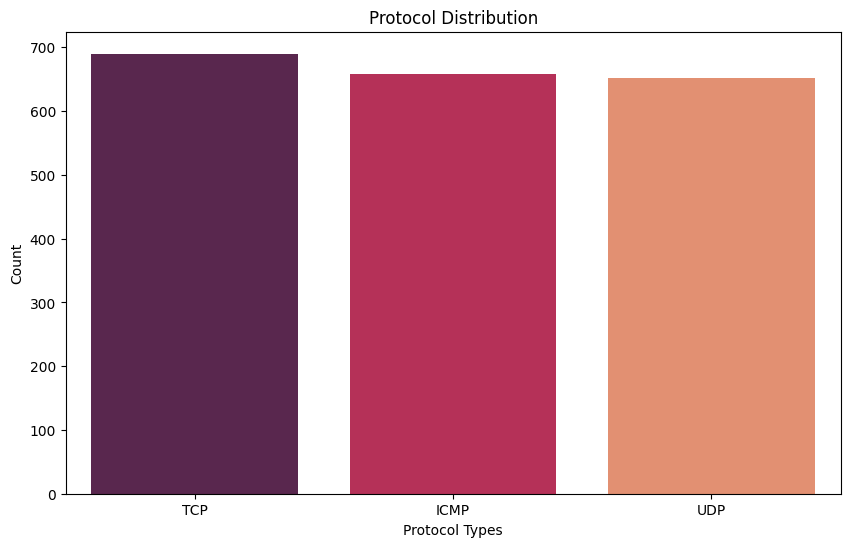

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

In [21]:
#Evaluating the distribution of network protocols amongst the network traffic
plt.figure(figsize=(10, 6))
sns.countplot(x='Protocol', data=df, palette='rocket', hue='Protocol')
plt.title('Protocol Distribution')
plt.xlabel('Protocol Types')
plt.ylabel('Count')
plt.show()
plt

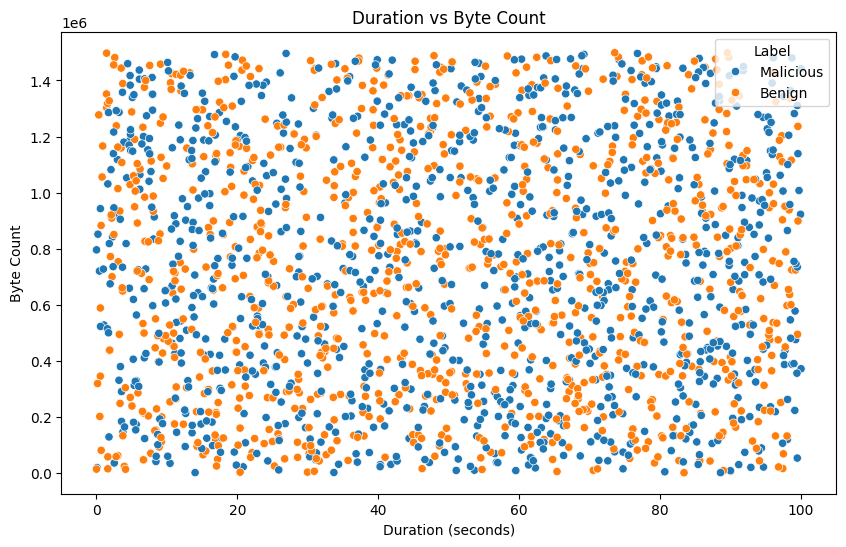

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Duration', y='ByteCount', data=df, hue='Label')
plt.title('Duration vs Byte Count')
plt.xlabel('Duration (seconds)')
plt.ylabel('Byte Count')
plt.show()

The Duration versus Byte Count scatterplot does not show a clear correlation between benign and malicious traffic

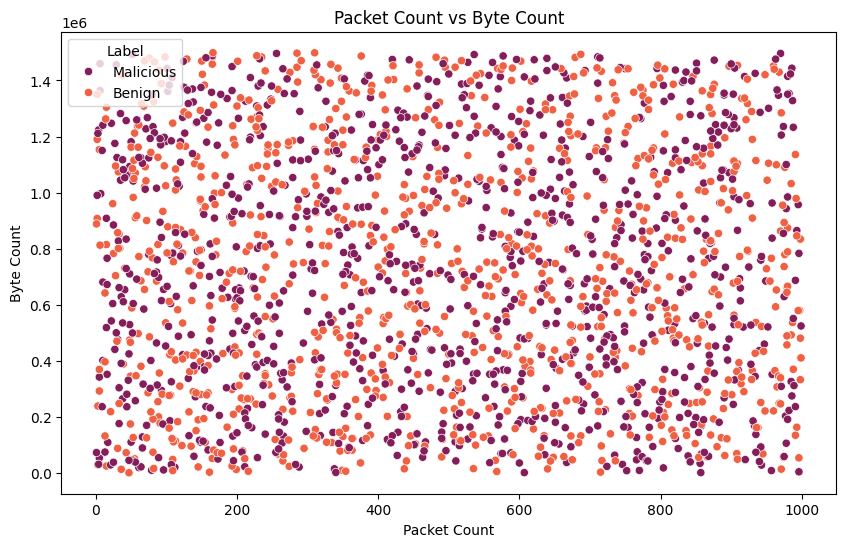

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PacketCount', y='ByteCount', data=df, hue='Label', palette='rocket')
plt.title('Packet Count vs Byte Count')
plt.xlabel('Packet Count')
plt.ylabel('Byte Count')
plt.show()

The Packet Count versus Byte Count scatterplot does not show a clear correlation between benign and malicious traffic

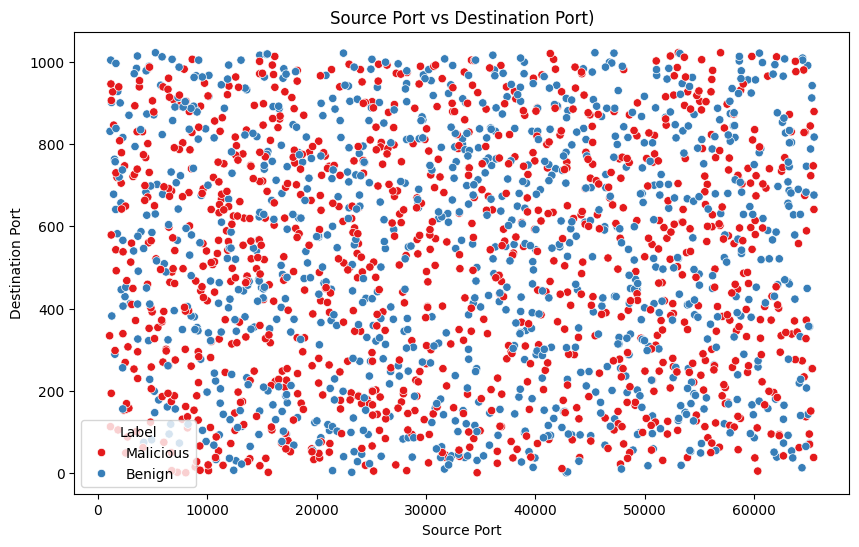

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SourcePort', y='DestinationPort', data=df, hue='Label', palette='Set1')
plt.title('Source Port vs Destination Port')
plt.xlabel('Source Port')
plt.ylabel('Destination Port')
plt.show()

The Source Port versus Destination Port scatterplot does not show a clear correlation between benign and malicious traffic

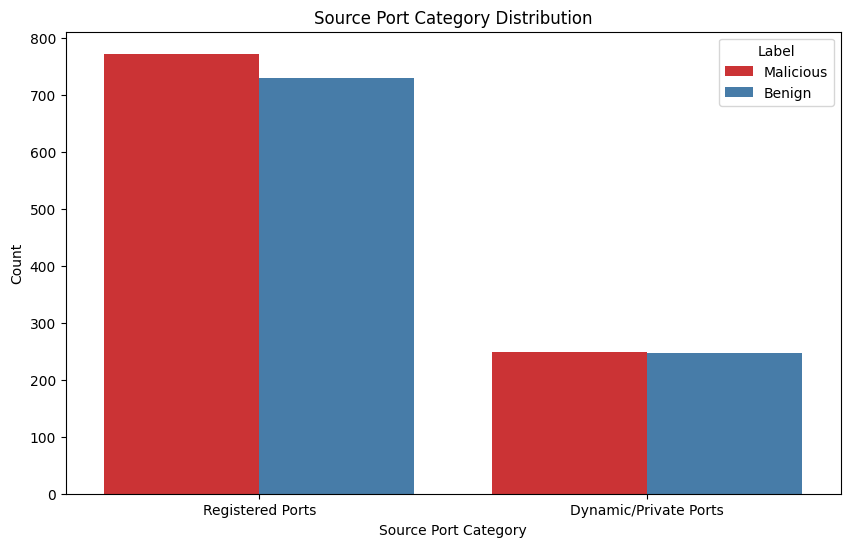

In [25]:
def categorize_port(port):
    if port <= 1023:
        return 'Well-Known Ports'
    elif port <= 49151:
        return 'Registered Ports'
    else:
        return 'Dynamic/Private Ports'

df['SourcePortCategory'] = df['SourcePort'].apply(categorize_port)
df['DestinationPortCategory'] = df['DestinationPort'].apply(categorize_port)

plt.figure(figsize=(10, 6))
sns.countplot(x='SourcePortCategory', data=df, hue='Label', palette='Set1')
plt.title('Source Port Category Distribution')
plt.xlabel('Source Port Category')
plt.ylabel('Count')
plt.show()


In [26]:
#Testing the accuracy of the def
print(categorize_port(80))
print(categorize_port(443))
print(categorize_port(12000))
print(categorize_port(53))
print(categorize_port(1024))

Well-Known Ports
Well-Known Ports
Registered Ports
Well-Known Ports
Registered Ports


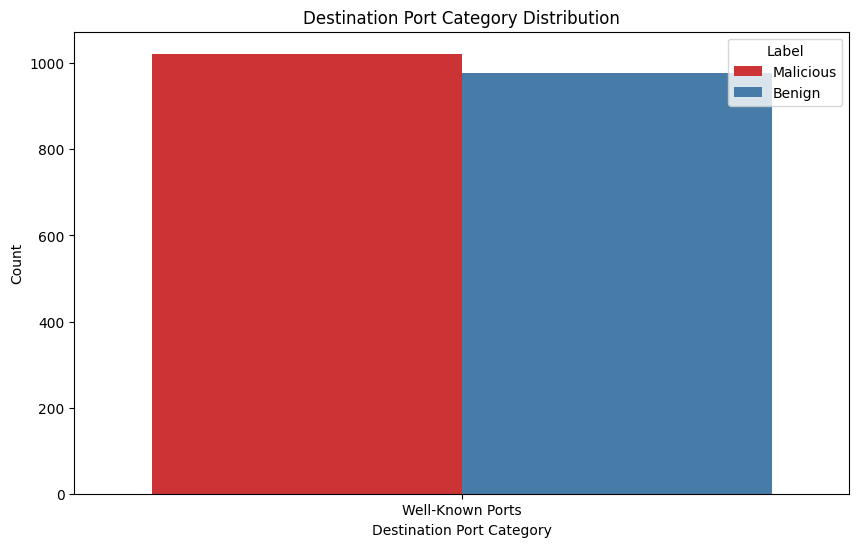

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(x='DestinationPortCategory', data=df, hue='Label', palette='Set1')
plt.title('Destination Port Category Distribution')
plt.xlabel('Destination Port Category')
plt.ylabel('Count')
plt.show()

# **Outlier Analysis**

In [28]:
outlier_summary = []

#Calculating Q1, Q3 & IQR
for col in ['PacketCount', 'ByteCount', 'Duration']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    #Defining Bounds
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    outliers = df[(df[col] > upper_bound) | (df[col] < lower_bound)]

    outlier_summary.append({
        'Column': col,
        'Number of Outliers': len(outliers),
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Percentage of Outliers': round(len(outliers) / len(df) * 100, 2)
    })

    print(f'Number of Outliers for {col}: {len(outliers)}')
pd.DataFrame(outlier_summary)

Number of Outliers for PacketCount: 0
Number of Outliers for ByteCount: 0
Number of Outliers for Duration: 0


,Column,Number of Outliers,Lower Bound,Upper Bound,Percentage of Outliers
0,PacketCount,0,-536.875000,1.508125e+03,0.0
1,ByteCount,0,-787447.250000,2.241551e+06,0.0
2,Duration,0,-51.397848,1.509336e+02,0.0


Identifying outliers amongst the PacketCount, ByteCount and Duration columns. These columns were selected because malformed or misconfigured packets and network errors can cause the packet sizes to swell and the duration to be abnormal.

# **Modeling**

In [29]:
X = df.drop(columns=['Label', 'SourceIP', 'DestinationIP'])
y = df['Label']

Dropping the SourceIP and DestinationIP features so the model doesnt memorizes the raw IP addresses

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
df.dtypes

,0
Duration,float64
Protocol,object
SourceIP,object
DestinationIP,object
SourcePort,int64
DestinationPort,int64
PacketCount,int64
ByteCount,int64
Label,object
DurationMinutes,float64


In [32]:
numeric_features = ['Duration', 'DestinationPort', 'SourcePort', 'PacketCount', 'ByteCount', 'DurationMinutes', 'PacketCountPerMinute']
categorical_features = ['Protocol', 'SourcePortCategory', 'DestinationPortCategory']

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

In [35]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

baseline_model.fit(X_train, y_train)
baseline_model.score(X_test, y_test)
baseline_prediction = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_prediction)

print(f"Baseline Accuracy: {baseline_accuracy}")

Baseline Accuracy: 0.5225


In [36]:
logreg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

logreg_model.fit(X_train, y_train)
logreg_model.score(X_test, y_test)
logreg_prediction = logreg_model.predict(X_test)
logreg_accuracy = accuracy_score(y_test, logreg_prediction)

print(f"Logistic Regression Accuracy: {logreg_accuracy}")


Logistic Regression Accuracy: 0.495


In [37]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)
rf_model.score(X_test, y_test)
rf_prediction = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_prediction)

print(f"Random Forest Accuracy: {rf_accuracy}")

Random Forest Accuracy: 0.515
